In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import glob
import rpy2.robjects as ro
import shutil
import seaborn as sns  

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import nebula_with_factors as nebula_utils

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "Striatum" # Striatum, DFC,SN
TYPE_DEG = "cNMF_nebula" #PCA_nebula, baseline_nebula, cNMF_nebula, gradient_score_nebula




if TISSUE == "Striatum":
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad"
elif (TISSUE == "DFC") | (TISSUE == "SN"):
    # no zones
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["age_of_death", "sex", "pct_counts_mt", "frac_intronic", "cohort",
                     #f"age_of_death:{CONTRAST_VARIABLE}"
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "total_counts"

# # mitluple etst correction pvalue thr
# ALPHA_MULTIPLE_TEST = 0.05
# LOGFC_THR=0.1
# PVAL_THR=0.05

# Save folder
DEG_FOLDER =F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}" # "/home/gdallagl/myworkdir/XDP/data/_old/nucseq_deg_pca_age" #F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"
os.makedirs(DEG_FOLDER, exist_ok=True)
DEG_FOLDER

'/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula'

In [3]:
ct_forcNMF = {
    "Striatum": ["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "eMSN_D1D2", "eMSN_StrioMat", "eMSN_NUDAP","Oligodendrocyte", "Astrocyte", "Microglia"],
    "DFC": ["Oligodendrocyte", "Astrocyte", "Microglia"],
    "SN": ["Oligodendrocyte", "Astrocyte", "Microglia"],
}

"""
1) request access to UGER macosko folder
2) ssh in UGER
	$ssh gdallagl@login02.broadinstitute.org
3) lunch tmudx
	$tmux
4) type
	$use UGER
5) request interactive node
	$/broad/software/scripts/ish -l h_vmem=10g -pe smp 4 -binding linear:4 -l h_rt=12:00:00 -l os='RedHat7'
6) cd your working folder
	$ cd /broad/macosko/gdallagl/cNMF
7) type
	$use UGER
8) run scirpt to open jupyer on website
	$./start_jupyter_cNMF.sh 
	*) paste link into browser


first run once the cell n order to egenrate the hlahy datset --> then upload on uger


to copy adata to google bucket (on VM terminal)

    TISSUE="DFC"
    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        gsutil cp /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/healthy_cNMF.h5ad \
            gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/healthy_cNMF.h5ad
    done

to copy form google bucket to auger (on UGER terminal)

    use UGER
    ish #alias to reaeust small ndoe
    use Google-Cloud-SDK

    TISSUE="DFC"
    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        mkdir -p /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/input
        gsutil cp gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/healthy_cNMF.h5ad \
            /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/input/
    done

Run facotrization on UGER

to copy from UGER to google bucket (on UGER terminal)

    use Google-Cloud-SDK
    for cell_type in Matrix_D1 Matrix_D2 Patch_D1 Patch_D2 eMSN_D1D2 eMSN_StrioMat eMSN_NUDAP Oligodendrocyte Astrocyte Microglia; do
        echo "Copying $cell_type..."

        gsutil -m cp -r \
            /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/output/final_results/* \
            gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/cNMF_run_healthy/
    done
    

to copy from google bucket to local (on VM terminal)

    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        mkdir -p /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/cNMF_run_healthy
        gsutil cp -r gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/cNMF_run_healthy/* \
            /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/cNMF_run_healthy/
    done

"""

'\n1) request access to UGER macosko folder\n2) ssh in UGER\n\t$ssh gdallagl@login02.broadinstitute.org\n3) lunch tmudx\n\t$tmux\n4) type\n\t$use UGER\n5) request interactive node\n\t$/broad/software/scripts/ish -l h_vmem=10g -pe smp 4 -binding linear:4 -l h_rt=12:00:00 -l os=\'RedHat7\'\n6) cd your working folder\n\t$ cd /broad/macosko/gdallagl/cNMF\n7) type\n\t$use UGER\n8) run scirpt to open jupyer on website\n\t$./start_jupyter_cNMF.sh \n\t*) paste link into browser\n\n\nfirst run once the cell n order to egenrate the hlahy datset --> then upload on uger\n\n\nto copy adata to google bucket (on VM terminal)\n\n    TISSUE="DFC"\n    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do\n        echo "Copying $cell_type..."\n        gsutil cp /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/healthy_cNMF.h5ad             gs://macosko_data/gdallagl/NucSeq/health

# Read adata

In [4]:
print("Loading adata... \ntissue:", TISSUE, "\ntype of DEG:", TYPE_DEG)
adata = sc.read_h5ad(ADATA_PATH)#, backed="r")
adata.obs.columns

###########################
#ATTENTION: use genenames for DEG
adata.var.index = adata.var["gene_symbol"]
###########################

###########################
#ATTENTION: remove "bad cell" ypes
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-"), :].copy()
###########################

###########################
#ATTENTION: be sure cell types have no space
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].str.replace(" ", "_")
###########################

###########################
#ATTENTION: remove bad quality samples
adata = adata[~adata.obs[CONTRAST_VARIABLE].isna()].copy()
###########################

Loading adata... 
tissue: Striatum 
type of DEG: cNMF_nebula


In [4]:
# RUN_ON_ZONES = False # if False, will run on ct

# if RUN_ON_ZONES:

#     ZONE_CT = "Astrocyte" #Astrocyte, Matrix_D1

#     # Each cell type has a better zonation level
#     if ZONE_CT in ["Matrix_D1", "Matrix_D2"]:
#         ZONE_VARIABLE = "zone_6" 
#     if ZONE_CT in ["Patch_D1", "Patch_D2", "eMSN_D1D2", "Astrocyte"]:
#         ZONE_VARIABLE = "zone_4"

#     adata = adata[
#         (adata.obs["ct_for_deg"] == ZONE_CT) & # only QC cells tat are matrix
#         (adata.obs[ZONE_VARIABLE].notna()) # only cells with zone annotation
#     ].to_memory().copy()
    
#     # chnage zone to be treated as ct
#     CT_FOR_DEG_VARIABLE = ZONE_VARIABLE

#     print(adata)
#     print(adata.obs.groupby([ZONE_VARIABLE, CONTRAST_VARIABLE]).size())

# Define gradient genes

In [4]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad.combined_p <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene"]]
df_grad

1241
1241


,mean_spearman,is_gradient_gene
gene,,
A1BG,-0.002360,False
A1BG-AS1,-0.007881,False
A1CF,0.007398,False
A2M,-0.002144,False
A2M-AS1,-0.000389,False
...,...,...
ENSG00000277836,NaN,False
ENSG00000278633,NaN,False
ENSG00000276017,-0.008289,False


# Calculate gradient score

In [6]:
# def calc_gradient_score(adata, df_grad, csv_save_path, col_corr="mean_spearman"):

#     print("ATTENTION: adata.X must be raw.")
#     print("ATTENTION: df_grad must have ONLY gradient genes and gene names as index.")

#     # Normalise
#     sc.pp.normalize_total(adata, target_sum=1e4)
#     sc.pp.log1p(adata)

#     # Calculate collim genes
#     common_genes = adata.var_names.intersection(df_grad.index)

#     # Subset to common genes
#     import scipy.sparse as sp
#     df_grad = df_grad.loc[common_genes]
#     X_grad_genes = adata[:, common_genes].X  # (n_cells × n_genes)
#     X_grad_genes = X_grad_genes.toarray() if sp.issparse(X_grad_genes) else np.asarray(X_grad_genes)


#     # calculate score
#     # more dorsal genes --> higher score
#     adata.obs["gradient_score"] = - X_grad_genes @ df_grad[col_corr].values

#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

#     # save df
#     df_scores = adata.obs[["gradient_score"]]
#     df_scores.to_csv(csv_save_path)


In [7]:
# # define genes for grad

# save_csv_path = f"{os.path.dirname(ADATA_PATH)}/gradient_scores.csv"

# if not os.path.exists(save_csv_path):

#     adata.X = adata.layers["counts"].copy()  # use raw counts for score calculation
#     df_grad_significant = df_grad[df_grad["is_gradient_gene"]]
#     calc_gradient_score(adata, df_grad_significant, save_csv_path)

# else:
#     df_scores = pd.read_csv(save_csv_path, index_col=0)
#     adata.obs = adata.obs.merge(df_scores, how="left", left_index=True, right_index=True, validate="one_to_one")
#     # Check that all cells have scores
#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

In [8]:
# sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data=adata.obs[adata.obs["broad_original_cell_type"] == "Striatum_Neuron"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[adata.obs["ct_for_deg"] == "Matrix"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[(adata.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"])) & (adata.obs["ct_for_deg"] == "Matrix")], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

In [9]:
# # Compare mean gradient score per donor
# if RUN_ON_ZONES:

#     sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

#     donor_zone_mean = (
#         adata.obs.groupby([SAMPLE_VARIABLE, CONTRAST_VARIABLE, "zone"])["gradient_score"]
#         .mean()
#         .reset_index()
#     )

#     sns.boxplot(data=donor_zone_mean, x="zone", y="gradient_score", hue=CONTRAST_VARIABLE)

# Define functions

## Nebula Gene Filtering & PCA Stopping Criteria

### Gene Filtering
1. Drop donors with < `min_cells_per_sample` cells.  
2. Keep genes expressed in ≥ `n_donors × min_cells_per_sample` cells.  
3. Keep genes with ≥ `min_counts` total counts.  
4. Skip analysis if:
   - Any condition has < `MIN_SAMPLES_PER_CONDITION` donors.  
   - Remaining genes ≤ `MIN_NUMBER_GENES_PER_ANALYSIS`.  

# Run for all ct

In [14]:
# sc.pl.umap(adata_ct, color=[CONTRAST_VARIABLE, "Group_name", "vireo_prob_doublet"], palette="tab20")
# pcs = [c for c in adata_ct.obs.columns if c.startswith("PC_")]
# DEG.check_corr_cov_in_design(adata_ct, vars_in_formula=[CONTRAST_VARIABLE, *pcs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")

sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]

['Astrocyte',
 'COP',
 'Da_CALB1_CALCR_CRYM',
 'Da_CALB1_TMEM200A',
 'Da_SOX6_AGTR1_EYA4',
 'Da_SOX6_GFRA2_PART1',
 'Da_SOX6_NXPH1',
 'Endothelial_BBB',
 'Ependymal',
 'Exc_5HT',
 'Exc_CYP2J2_CRH',
 'Exc_HDC',
 'Exc_LHX9_FBN2',
 'Exc_LMX1A_PITX2',
 'Exc_NEUROD1',
 'Exc_PAX5_F13A1',
 'Exc_POSTN',
 'Exc_SALL1_TDO2',
 'Exc_SATB2_TBR1',
 'Fibroblasts',
 'Inh_EGFLAM',
 'Inh_EXPH5_TFAP2B',
 'Inh_OTX2_CASR',
 'Inh_PAX5',
 'Inh_PENK',
 'Inh_PPP1R17_PCP2',
 'Inh_PPP1R1B_DRD3',
 'Inh_PVALB_SIX3',
 'Inh_SLC17A6_EBF3',
 'Inh_VIP_PROX1',
 'Macrophages',
 'Microglia',
 'Monocytes',
 'OPC',
 'Oligodendrocyte',
 'Pericytes',
 'SmoothMuscleCells',
 'Tcell']

In [5]:
for ct in sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]:

    ct="Oligodendrocyte"
    if ct.startswith("-"):
        continue

    if (TYPE_DEG == "cNMF_nebula") and (ct not in ct_forcNMF[TISSUE]):
        print(f"Skipping {ct} because it's not in the list of cell types to run cNMF on.")
        continue

    print("\n\n######################\n",ct, "\n######################\n")

    # Select single ct
    adata_ct = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].to_memory().copy()
    adata_ct.X = adata_ct.layers["counts"].copy() 
    print(np.array_equal(adata_ct.X.data, adata_ct.X.data.astype(int)) if hasattr(adata_ct.X, 'data') else np.array_equal(adata_ct.X, adata_ct.X.astype(int)))

    # adata_ct = adata_ct[adata_ct.obs["zone"].isin(["4"])].copy() # only keep control and XDP for this analsys
    # print(adata_ct)

    # Define saving apthjs
    ADATA_PATH_QS = f"{DEG_FOLDER}/{ct}/tmp_{os.path.splitext(os.path.basename(ADATA_PATH))[0]}_{ct}_for_nebula.qs"
    SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
    os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
    print(ADATA_PATH_QS)

    #break

    if TYPE_DEG == "cNMF_nebula":
        # For cNMF, we need to provide the spectra file path (with gene names as index)
        matches = glob.glob(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/cNMF_nebula/{ct}/cNMF_run_healthy/*.spectra.*.consensus.txt")
        if len(matches) == 0:
            # First time for this tissue/ct: no spectra yet.
            # run_nebula_with_factors will save healthy_cNMF.h5ad and return None.
            print(f"No spectra found for {ct} — will save healthy h5ad for cNMF training on UGER.")
            CNMF_SPECTRA_PATH = None
        elif len(matches) > 1:
            raise ValueError(f"Expected 1 spectra file for {ct}, found {len(matches)}: {matches}")
        else:
            CNMF_SPECTRA_PATH = matches[0]
    else:
        CNMF_SPECTRA_PATH = None


    # Run enire pipeline for this ct
    nebula_utils.run_nebula_with_factors(
        adata_ct, 
        ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
        CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
        SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
        N_PCS_TO_USE=None, # default knee method
        variance_threshold=None,delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
        MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000,
        
        # Attention: spectra file expected to be in fixed place
            #/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/cNMF_nebula/{ct}/cNMF_run_healthy/cNMF_spectra.txt
        CNMF_SPECTRA_PATH=CNMF_SPECTRA_PATH
    )

    break
    



######################
 Oligodendrocyte 
######################

True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Oligodendrocyte/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Oligodendrocyte_for_nebula.qs
No spectra found for Oligodendrocyte — will save healthy h5ad for cNMF training on UGER.
True
ATTENTION: .X must be raw!
Retained donors : 47
Filtered genes  : 38601 -> 16373 (min_cells=470, min_counts=50)
Running Factor calculation on Healthy...


/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:451: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]
... storing 'ct_for_deg' as categorical


Saved healthy h5ad. Run cNMF on remote server, then re-run.
NOW RUN cNMF on AUGER using this h5ad, then save the resulting GEP loadings and scores in the same folder, and re-run this function to continue with projection/merging/nebula steps.


In [ ]:
adata.obs[adata.obs[CONTRAST_VARIABLE].isna()][SAMPLE_VARIABLE].unique()

['SCF_21_036B']
Categories (45, object): ['PCMC-16-011', 'PCMC-16-012', 'SCF-18-003', 'SCF-18-004', ..., 'SCF_23_072CF', 'SCF_23_074CF', 'SCF_23_075CM', 'SCF_23_079CF']

# Run for all Zones 
### ONLY STR  --> omly tissue with zones
### cNMF in zone uses the data/files of the cell type used for mapping

In [5]:
if TISSUE != "Striatum":
    exit()

In [6]:
# Map: cell types that have zone analysis → their zone variable
# each cell type has  a better zonation level
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}
# adata stays untouched here — no more global mutation


In [7]:
DEG_FOLDER

'/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula'

In [8]:
ZONE_CT_MAP.items()

dict_items([('Matrix_D1', 'zone'), ('Matrix_D2', 'zone'), ('Patch_D1', 'zone_4'), ('Patch_D2', 'zone_4'), ('eMSN_D1D2', 'zone_4'), ('Astrocyte', 'zone_4')])

Using spectra: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt


######################
Astrocyte / zone_4=1 / cNMF_nebula
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1
True
ATTENTION: .X must be raw!
Retained donors : 47
Filtered genes  : 38601 -> 12878 (min_cells=470, min_counts=50)
Running Factor calculation on Healthy...


/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:451: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Found existing cNMF spectra at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt, skipping cNMF training and proceeding to projection step.
Saved healthy GEP projections: 1977 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 6112 cells, 11 GEPs
Saving h5ad file...
adata intact: 8089 cells, 12878 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


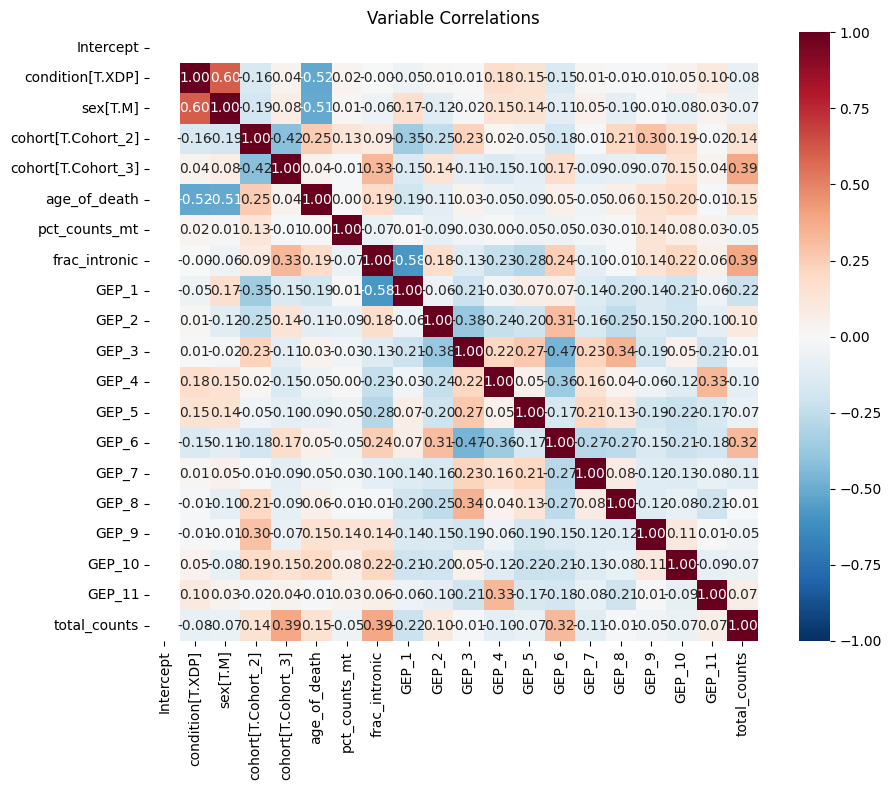

              variable         VIF
0            Intercept  464.954367
13               GEP_6    3.433664
8                GEP_1    2.827076
10               GEP_3    2.700274
17              GEP_10    2.477679
3   cohort[T.Cohort_2]    2.473131
9                GEP_2    2.462106
7        frac_intronic    2.357145
18              GEP_11    2.343027
1     condition[T.XDP]    2.185774
4   cohort[T.Cohort_3]    2.144866
16               GEP_9    2.097945
2             sex[T.M]    2.090622
15               GEP_8    1.930366
19        total_counts    1.824973
5         age_of_death    1.787284
12               GEP_5    1.569213
11               GEP_4    1.568697
14               GEP_7    1.485424
6        pct_counts_mt    1.064202

binary identifiability test. False


2026-04-16 14:59:51 | [WARNING] R callback write-console: condition: factor | example: XDP
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: donor_id: character | example: SCF-20-025
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: age_of_death: numeric | example: 54
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.162876852324987
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.679666889164362
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.224756625405671
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.0392135865215256
  
2026-04-16 14:59:51 | [WARNING] R callback write-console: GEP_3: numeric | exampl

factor     beta       se      p_value          fdr
 GEP_8 0.869486 0.148495 4.760881e-09 5.236969e-08
GEP_10 1.136950 0.235965 1.447916e-06 7.963535e-06
 GEP_9 0.958061 0.239489 6.322587e-05 2.318282e-04
 GEP_5 0.728349 0.195328 1.923541e-04 5.289737e-04
GEP_11 0.931531 0.335178 5.449112e-03 1.006056e-02
 GEP_6 0.570759 0.205536 5.487581e-03 1.006056e-02
 GEP_3 0.515294 0.211999 1.507223e-02 2.368493e-02
 GEP_4 0.440500 0.217441 4.278126e-02 5.261151e-02
 GEP_7 0.424829 0.209972 4.304578e-02 5.261151e-02
 GEP_1 0.330468 0.169035 5.058000e-02 5.563801e-02
 GEP_2 0.563887 0.301246 6.122712e-02 6.122712e-02
Significant GEPs (FDR<0.05): ['GEP_8', 'GEP_10', 'GEP_9', 'GEP_5', 'GEP_11', 'GEP_6', 'GEP_3']
Saving qs file...
	Saving files for R coversion...


2026-04-16 15:03:44 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-04-16 15:03:44 | [WARNING] R callback write-console: Loading required package: sp
  


	Building R obj...


...

[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:451: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Found existing cNMF spectra at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt, skipping cNMF training and proceeding to projection step.
Saved healthy GEP projections: 2668 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 6765 cells, 11 GEPs
Saving h5ad file...
adata intact: 9433 cells, 13133 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


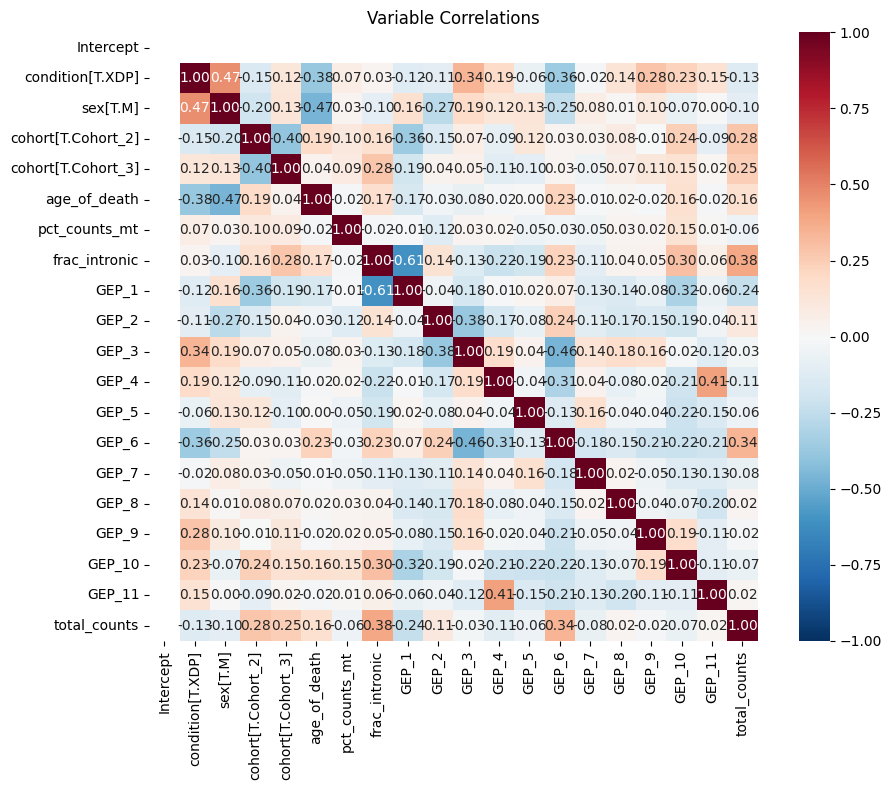

              variable         VIF
0            Intercept  503.198081
17              GEP_10    4.161226
13               GEP_6    3.648289
10               GEP_3    2.916600
8                GEP_1    2.837090
1     condition[T.XDP]    2.831210
18              GEP_11    2.541385
3   cohort[T.Cohort_2]    2.521424
7        frac_intronic    2.397025
9                GEP_2    2.272133
4   cohort[T.Cohort_3]    2.083436
2             sex[T.M]    1.986902
15               GEP_8    1.928329
11               GEP_4    1.788522
19        total_counts    1.773908
5         age_of_death    1.768721
12               GEP_5    1.606974
16               GEP_9    1.440307
14               GEP_7    1.368717
6        pct_counts_mt    1.094718

binary identifiability test. False


2026-04-16 15:06:46 | [WARNING] R callback write-console: condition: factor | example: Control
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: donor_id: character | example: SCF-22-054CM
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: age_of_death: numeric | example: 51
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0280938334035679
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.738555053838138
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.11023022316391
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.070490846427879
  
2026-04-16 15:06:46 | [WARNING] R callback write-console: GEP_3: numeric | e

factor     beta       se      p_value          fdr
 GEP_8 1.568796 0.259759 1.546543e-09 1.701198e-08
GEP_10 1.638857 0.281029 5.488938e-09 3.018916e-08
 GEP_9 1.571751 0.297824 1.309903e-07 4.802979e-07
 GEP_3 1.588713 0.318589 6.141446e-07 1.688898e-06
 GEP_6 1.101628 0.233614 2.410116e-06 5.302256e-06
 GEP_5 1.217299 0.281527 1.532849e-05 2.810223e-05
GEP_11 1.409400 0.343979 4.179119e-05 6.567187e-05
 GEP_4 0.974366 0.240356 5.038371e-05 6.927760e-05
 GEP_2 1.113730 0.303507 2.429966e-04 2.969958e-04
 GEP_1 0.690862 0.218738 1.586335e-03 1.744969e-03
 GEP_7 0.624421 0.263086 1.762299e-02 1.762299e-02
Significant GEPs (FDR<0.05): ['GEP_8', 'GEP_10', 'GEP_9', 'GEP_3', 'GEP_6', 'GEP_5', 'GEP_11', 'GEP_4', 'GEP_2', 'GEP_1', 'GEP_7']
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-04-16 15:11:27 | [WARNING] R callback write-console: Warning:  
2026-04-16 15:11:27 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

In [ ]:
for zone_ct, zone_variable in ZONE_CT_MAP.items():

    if zone_ct != "Astrocyte":
        continue
    
    if zone_ct not in adata.obs["ct_for_deg"].values:
        print(f"WARNING: {zone_ct} not in adata, skipping")
        continue

    # cNMF of celltype_X_zone are not recualted (ie re-facotrize for each zone)
    #  we just use the same cNMF spectra as for the whole cell type, but run Nebula separately for each zone (with the zone as a covariate in the model)
        # Reuse the spectra from the full cell-type cNMF run (already computed)
    if TYPE_DEG == "cNMF_nebula":
        matches = glob.glob(f"{DEG_FOLDER}/{zone_ct}/cNMF_run_healthy/*.spectra.*.consensus.txt")
        if len(matches) != 1:
            print(f"WARNING: Expected 1 spectra file for {zone_ct}, found {len(matches)}: {matches}. Skipping.")
            continue
        CNMF_SPECTRA_PATH = matches[0]
        print(f"Using spectra: {CNMF_SPECTRA_PATH}")
    else:
        CNMF_SPECTRA_PATH = None

    adata_zone = adata[
        (adata.obs["ct_for_deg"] == zone_ct) & # filter to QC labels
        (adata.obs[zone_variable].notna()) # only cells with zone annotation
    ].to_memory().copy()

    for zone in sorted(adata_zone.obs[zone_variable].unique()):
        print(f"\n\n######################\n{zone_ct} / {zone_variable}={zone} / {TYPE_DEG}\n######################\n")

        adata_ct = adata_zone[adata_zone.obs[zone_variable] == zone].to_memory().copy()
        adata_ct.X = adata_ct.layers["counts"].copy()

        subfolder = f"{zone_ct}_by_{zone_variable}/{zone}"
        ADATA_PATH_QS = f"{DEG_FOLDER}/{subfolder}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
        SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
        os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
        print(SAVE_HEALTHY_PCA_RESULT)

        nebula_utils.run_nebula_with_factors(
            adata_ct,
            ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
            CONTRAST_VARIABLE, CONTRAST_BASELINE, CONTRAST_STIM,
            SAMPLE_VARIABLE, LIBRARY_SIZE_COL, COVARIATES_FOR_DEG,
            N_PCS_TO_USE=None, variance_threshold=None, delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
            MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000,
            CNMF_SPECTRA_PATH=CNMF_SPECTRA_PATH
        )


    #break
